In [4]:
import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import cv2
from sklearn.model_selection import train_test_split
import tensorflow as tf
from tensorflow.keras import layers, models

In [5]:
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [6]:
# Reemplaza 'Ruta/Hacia/Tu/Archivo' con la ruta real en tu Drive
!unzip -q "/content/drive/MyDrive/Flooded Area Segmentation/archive (1).zip" -d "/content/dataset/"

In [7]:
def load_data(img_dir, mask_dir, target_size=(256, 256)):
    images = []
    masks = []

    # Listamos archivos de imagen
    img_names = [f for f in sorted(os.listdir(img_dir)) if f.lower().endswith('.jpg')]
    print(f"Se encontraron {len(img_names)} imágenes .jpg")

    for name in img_names:
        # Extraer solo el nombre sin extensión (ej: '0')
        base_name = os.path.splitext(name)[0]

        img_path = os.path.join(img_dir, name)
        # Construir la ruta de la máscara forzando la extensión .png
        mask_path = os.path.join(mask_dir, base_name + '.png')

        if not os.path.exists(mask_path):
            # Intentar también con .jpg por si acaso, o imprimir error
            print(f"Advertencia: No se encontró máscara para {name} (buscado como {base_name}.png)")
            continue

        img = cv2.imread(img_path)
        mask = cv2.imread(mask_path, cv2.IMREAD_GRAYSCALE)

        if img is None or mask is None:
            continue

        # Procesamiento estándar
        img = cv2.resize(img, target_size) / 255.0
        mask = cv2.resize(mask, target_size)
        mask = np.expand_dims(mask, axis=-1) / 255.0

        images.append(img)
        masks.append(mask)

    return np.array(images), np.array(masks)

X, y = load_data('/content/dataset/Image', '/content/dataset/Mask')

Se encontraron 290 imágenes .jpg


In [8]:
if len(X) > 0:
    print(f"¡Éxito! Datos listos.")
    print(f"Forma de imágenes (X): {X.shape}") # Debería ser (N, 256, 256, 3)
    print(f"Forma de máscaras (y): {y.shape}") # Debería ser (N, 256, 256, 1)
else:
    print("Algo salió mal. Verifica que los números de los nombres coincidan exactamente.")

¡Éxito! Datos listos.
Forma de imágenes (X): (290, 256, 256, 3)
Forma de máscaras (y): (290, 256, 256, 1)


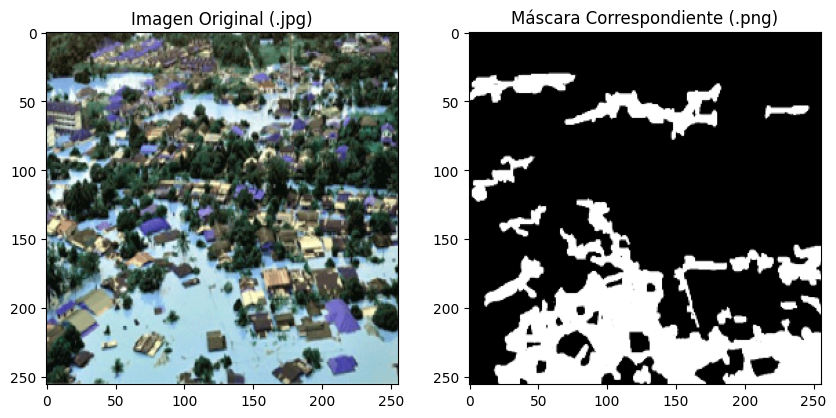

In [9]:
import matplotlib.pyplot as plt

plt.figure(figsize=(10, 5))
plt.subplot(1, 2, 1)
plt.imshow(X[0])
plt.title("Imagen Original (.jpg)")
plt.subplot(1, 2, 2)
plt.imshow(y[0].squeeze(), cmap='gray')
plt.title("Máscara Correspondiente (.png)")
plt.show()

In [10]:
from sklearn.model_selection import train_test_split

# Dividimos los datos cargados en X e y
X_train, X_val, y_train, y_val = train_test_split(X, y, test_size=0.2, random_state=42)

print(f"Imágenes para entrenar: {len(X_train)}")
print(f"Imágenes para validar: {len(X_val)}")

Imágenes para entrenar: 232
Imágenes para validar: 58


In [11]:
import tensorflow as tf
from tensorflow.keras import layers, models

def build_unet(input_shape=(256, 256, 3)):
    inputs = layers.Input(input_shape)

    # --- ENCODER (Ruta de Contracción) ---
    # Identifica el contexto y las características (ej: ¿hay agua?)
    c1 = layers.Conv2D(32, (3, 3), activation='relu', padding='same')(inputs)
    p1 = layers.MaxPooling2D((2, 2))(c1)

    c2 = layers.Conv2D(64, (3, 3), activation='relu', padding='same')(p1)
    p2 = layers.MaxPooling2D((2, 2))(c2)

    # --- BRIDGE ---
    b1 = layers.Conv2D(128, (3, 3), activation='relu', padding='same')(p2)

    # --- DECODER (Ruta de Expansión) ---
    # Permite la localización precisa píxel por píxel
    u1 = layers.UpSampling2D((2, 2))(b1)
    m1 = layers.concatenate([u1, c2])
    c3 = layers.Conv2D(64, (3, 3), activation='relu', padding='same')(m1)

    u2 = layers.UpSampling2D((2, 2))(c3)
    m2 = layers.concatenate([u2, c1])
    c4 = layers.Conv2D(32, (3, 3), activation='relu', padding='same')(m2)

    # --- SALIDA ---
    # Clasificación binaria: 0 (tierra) o 1 (agua)
    outputs = layers.Conv2D(1, (1, 1), activation='sigmoid')(c4)

    model = models.Model(inputs, outputs, name="U-Net_Flood_Segmentation")

    # Compilación con métrica IoU
    model.compile(
        optimizer='adam',
        loss='binary_crossentropy',
        metrics=['accuracy', tf.keras.metrics.MeanIoU(num_classes=2)]
    )

    return model


In [12]:
# Construir el modelo (asegúrate de haber corrido la celda de build_unet antes)
model = build_unet()

# Entrenamiento
history = model.fit(
    X_train, y_train,
    validation_data=(X_val, y_val),
    epochs=20, # Puedes aumentar esto a 30 si ves que sigue mejorando
    batch_size=16
)

Epoch 1/20
15/15 ━━━━━━━━━━━━━━━━━━━━ 240s 16s/step - accuracy: 0.6327 - loss: 0.6087 - mean_io_u: 0.3024 - val_accuracy: 0.7524 - val_loss: 0.6233 - val_mean_io_u: 0.3062
Epoch 2/20
15/15 ━━━━━━━━━━━━━━━━━━━━ 269s 16s/step - accuracy: 0.7223 - loss: 0.5583 - mean_io_u: 0.3024 - val_accuracy: 0.7741 - val_loss: 0.4928 - val_mean_io_u: 0.3062
Epoch 3/20
15/15 ━━━━━━━━━━━━━━━━━━━━ 253s 16s/step - accuracy: 0.7823 - loss: 0.4755 - mean_io_u: 0.3024 - val_accuracy: 0.8075 - val_loss: 0.4202 - val_mean_io_u: 0.3062
Epoch 4/20
15/15 ━━━━━━━━━━━━━━━━━━━━ 263s 16s/step - accuracy: 0.7801 - loss: 0.4609 - mean_io_u: 0.3024 - val_accuracy: 0.7923 - val_loss: 0.4503 - val_mean_io_u: 0.3062
Epoch 5/20
15/15 ━━━━━━━━━━━━━━━━━━━━ 256s 15s/step - accuracy: 0.7911 - loss: 0.4457 - mean_io_u: 0.3024 - val_accuracy: 0.8155 - val_loss: 0.3993 - val_mean_io_u: 0.3062
Epoch 6/20
15/15 ━━━━━━━━━━━━━━━━━━━━ 269s 16s/step - accuracy: 0.7862 - loss: 0.4528 - mean_io_u: 0.3024 - val_accuracy: 0.8135 - val_loss:

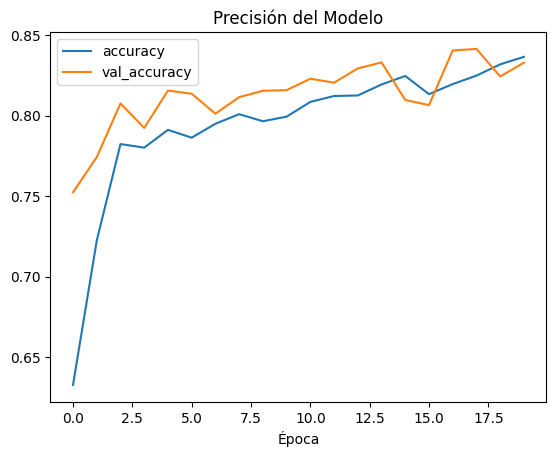

1/1 ━━━━━━━━━━━━━━━━━━━━ 2s 2s/step


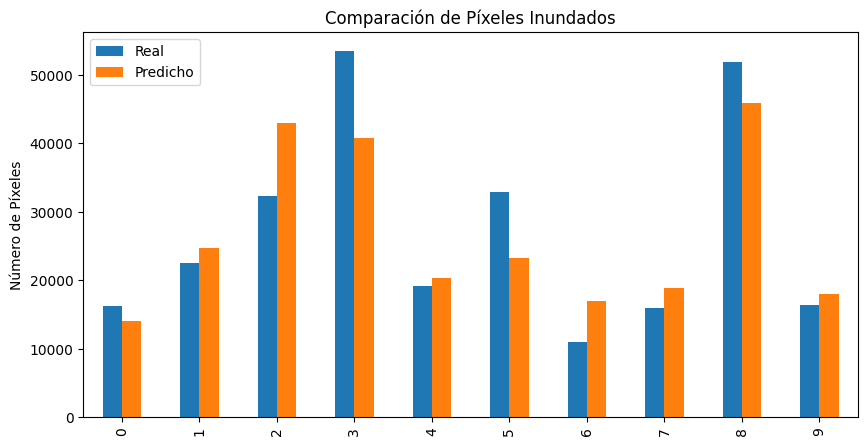

In [13]:
import pandas as pd
import matplotlib.pyplot as plt

# 1. Gráfica de Aprendizaje
df_hist = pd.DataFrame(history.history)
df_hist[['accuracy', 'val_accuracy']].plot(title="Precisión del Modelo")
plt.xlabel("Época")
plt.show()

# 2. Comparativa de Áreas (Muestreo de 10 imágenes)
preds = model.predict(X_val[:10])
stats = []

for i in range(10):
    real_area = np.sum(y_val[i] > 0.5)
    pred_area = np.sum(preds[i] > 0.5)
    stats.append({"Real": real_area, "Predicho": pred_area})

df_stats = pd.DataFrame(stats)
df_stats.plot(kind='bar', figsize=(10, 5), title="Comparación de Píxeles Inundados")
plt.ylabel("Número de Píxeles")
plt.show()

2/2 ━━━━━━━━━━━━━━━━━━━━ 16s 6s/step


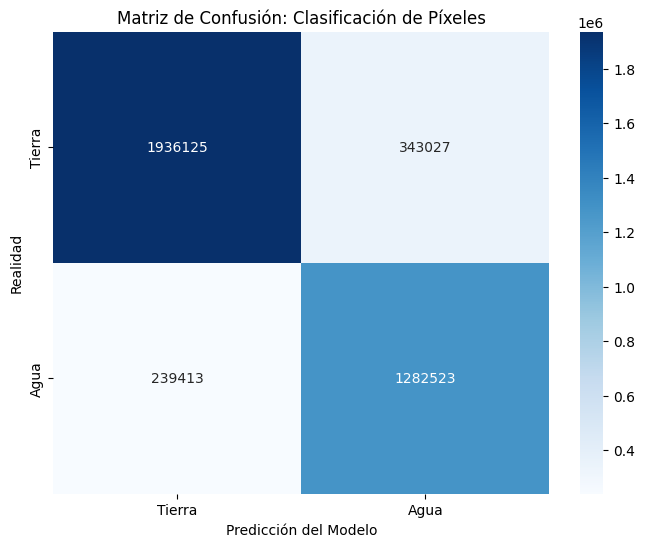

In [14]:
from sklearn.metrics import confusion_matrix
import seaborn as sns

def graficar_matriz_confusion(y_real, y_pred):
    # Aplanar las imágenes para tratarlas como una lista de píxeles
    y_real_flat = y_real.flatten() > 0.5
    y_pred_flat = y_pred.flatten() > 0.5

    # Calcular matriz
    cm = confusion_matrix(y_real_flat, y_pred_flat)

    # Visualización profesional
    plt.figure(figsize=(8, 6))
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
                xticklabels=['Tierra', 'Agua'],
                yticklabels=['Tierra', 'Agua'])
    plt.title('Matriz de Confusión: Clasificación de Píxeles')
    plt.ylabel('Realidad')
    plt.xlabel('Predicción del Modelo')
    plt.show()

# Ejecución (usando el set de validación)
preds_val = model.predict(X_val)
graficar_matriz_confusion(y_val, preds_val)

1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 1s/step


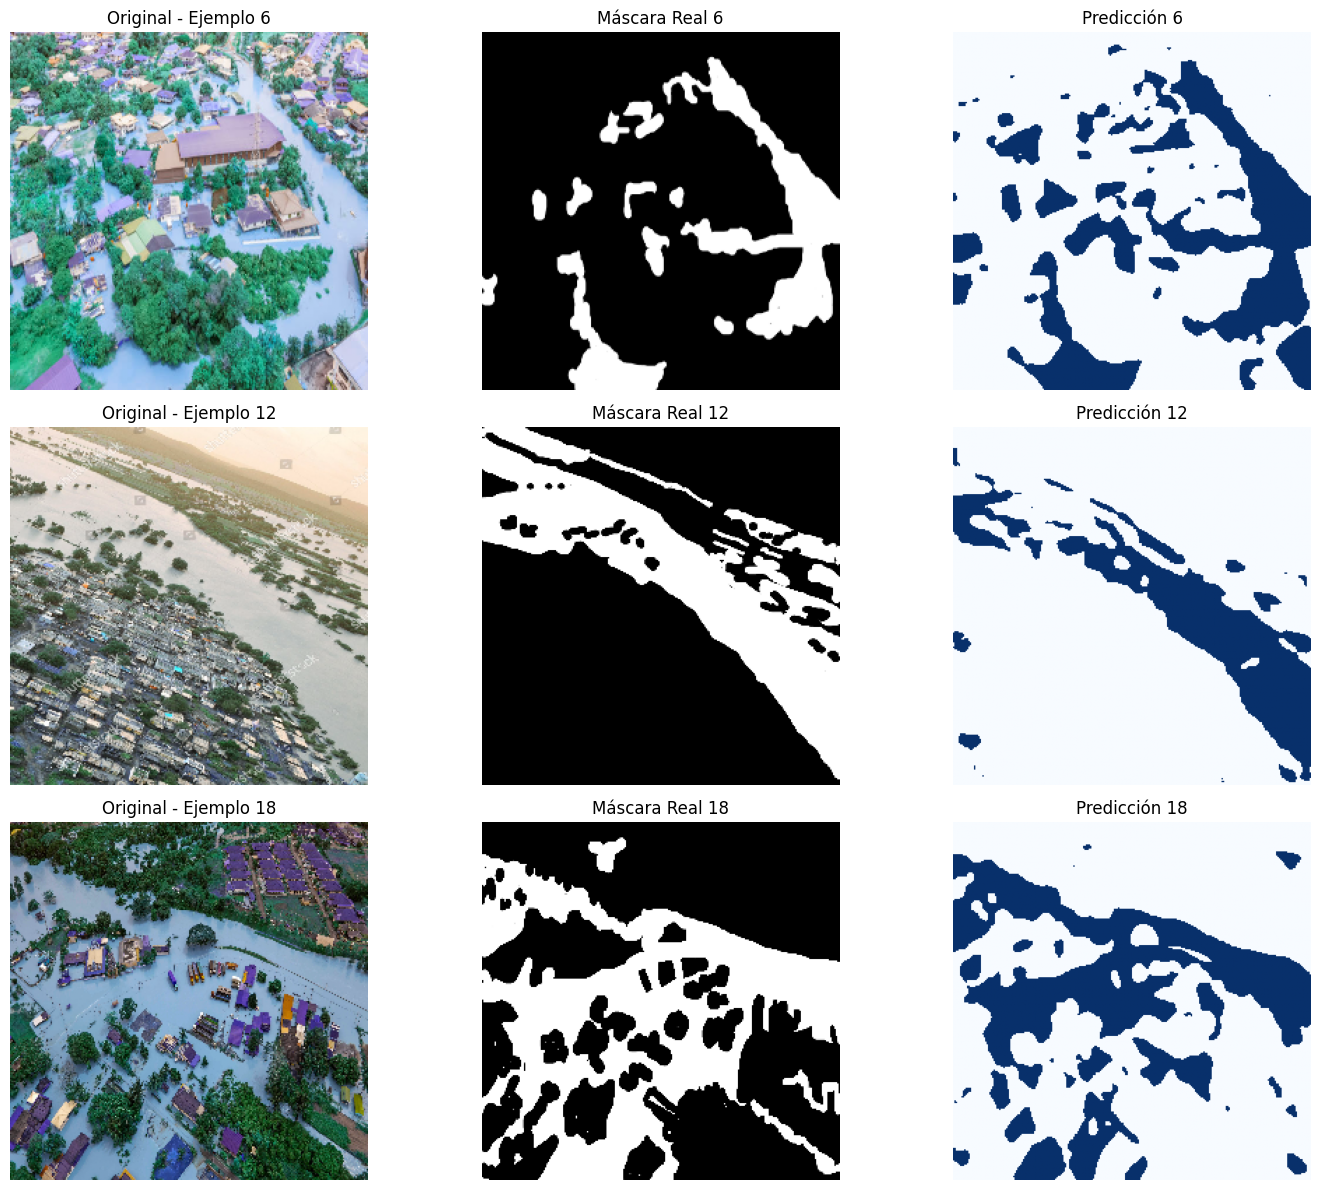

In [17]:
import matplotlib.pyplot as plt

def visualizar_multiples_predicciones(indices, X_val, y_val, model):
    # Generar predicciones para los índices seleccionados
    samples = X_val[indices]
    preds = model.predict(samples)

    plt.figure(figsize=(15, 12))

    for i, idx in enumerate(indices):
        # 1. Imagen Original (Columna 1)
        plt.subplot(3, 3, i*3 + 1)
        plt.imshow(X_val[idx])
        plt.title(f"Original - Ejemplo {idx}")
        plt.axis('off')

        # 2. Máscara Real (Columna 2)
        plt.subplot(3, 3, i*3 + 2)
        plt.imshow(y_val[idx].squeeze(), cmap='gray')
        plt.title(f"Máscara Real {idx}")
        plt.axis('off')

        # 3. Predicción del Modelo (Columna 3)
        plt.subplot(3, 3, i*3 + 3)
        # Aplicamos el umbral de 0.5 para binarizar la salida [cite: 29]
        plt.imshow(preds[i].squeeze() > 0.5, cmap='Blues')
        plt.title(f"Predicción {idx}")
        plt.axis('off')

    plt.tight_layout()
    plt.show()

# Ejemplo de uso con 3 índices diferentes
visualizar_multiples_predicciones([6, 12, 18], X_val, y_val, model)

In [16]:
# Guardar el modelo en formato estándar de Keras
model.save('flood_unet_model.h5')
print("Modelo exportado correctamente como flood_unet_model.h5")

Modelo exportado correctamente como flood_unet_model.h5


1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 806ms/step


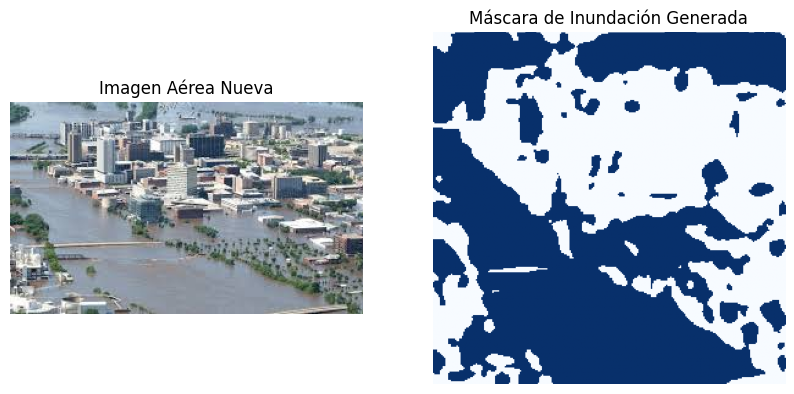

In [18]:
import cv2
import numpy as np
import matplotlib.pyplot as plt
from tensorflow.keras.models import load_model

def procesar_nueva_imagen(ruta_imagen, ruta_modelo='flood_unet_model.h5'):
    # 1. Cargar el modelo entrenado
    trained_model = load_model(ruta_modelo, compile=False)

    # 2. Leer y preprocesar la imagen
    original_img = cv2.imread(ruta_imagen)
    img_rgb = cv2.cvtColor(original_img, cv2.COLOR_BGR2RGB)
    img_input = cv2.resize(img_rgb, (256, 256)) / 255.0
    img_input = np.expand_dims(img_input, axis=0)

    # 3. Predicción (Generar Máscara)
    prediction = trained_model.predict(img_input)[0]
    mask = (prediction > 0.5).astype(np.uint8) * 255

    # 4. Visualización de resultados
    plt.figure(figsize=(10, 5))
    plt.subplot(1, 2, 1)
    plt.imshow(img_rgb)
    plt.title("Imagen Aérea Nueva")
    plt.axis('off')

    plt.subplot(1, 2, 2)
    plt.imshow(mask.squeeze(), cmap='Blues')
    plt.title("Máscara de Inundación Generada")
    plt.axis('off')
    plt.show()

    return mask

# Ejemplo de uso:
mascara_final = procesar_nueva_imagen('/content/drive/MyDrive/Flooded Area Segmentation/example_image.jpg')